**Trees Assignment**: Decision Trees, Random Forest, AdaBoost, XGBoost

---



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, precision_recall_curve, roc_curve, roc_auc_score, average_precision_score, auc, classification_report, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
from sklearn.pipeline import Pipeline
import graphviz

**Pre-Processing**

---



In [ ]:
# read csv into dataframe
df = pd.read_csv('https://raw.githubusercontent.com/ekandikattu/CS4372/refs/heads/main/Trees/winequality-white.csv', sep=';')

In [ ]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [ ]:
df.shape

(4898, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


In [ ]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000
mean,6.854788,0.278241,0.334192,6.391415,0.045772,35.308085,138.360657,0.994027,3.188267,0.489847,10.514267,5.877909
std,0.843868,0.100795,0.121020,5.072058,0.021848,17.007137,42.498065,0.002991,0.151001,0.114126,1.230621,0.885639
min,3.800000,0.080000,0.000000,0.600000,0.009000,2.000000,9.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.300000,0.210000,0.270000,1.700000,0.036000,23.000000,108.000000,0.991723,3.090000,0.410000,9.500000,5.000000
50%,6.800000,0.260000,0.320000,5.200000,0.043000,34.000000,134.000000,0.993740,3.180000,0.470000,10.400000,6.000000
75%,7.300000,0.320000,0.390000,9.900000,0.050000,46.000000,167.000000,0.996100,3.280000,0.550000,11.400000,6.000000
max,14.200000,1.100000,1.660000,65.800000,0.346000,289.000000,440.000000,1.038980,3.820000,1.080000,14.200000,9.000000


Check for Data Consistency



In [ ]:
df.isna().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [ ]:
df.duplicated().sum()

np.int64(937)

In [ ]:
# We have 937 rows of duplicate data
df = df.drop_duplicates().reset_index(drop=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.shape

(3961, 12)

Examining Features vs Target

In [ ]:
# Features/Attributes
attributes = df.columns[:-1]
attributes

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol'],
      dtype='object')

In [ ]:
# Target
target = df.columns[-1]
target

'quality'

In [ ]:
df[target].value_counts()

,count
quality,
6,1788
5,1175
7,689
4,153
8,131
3,20
9,5


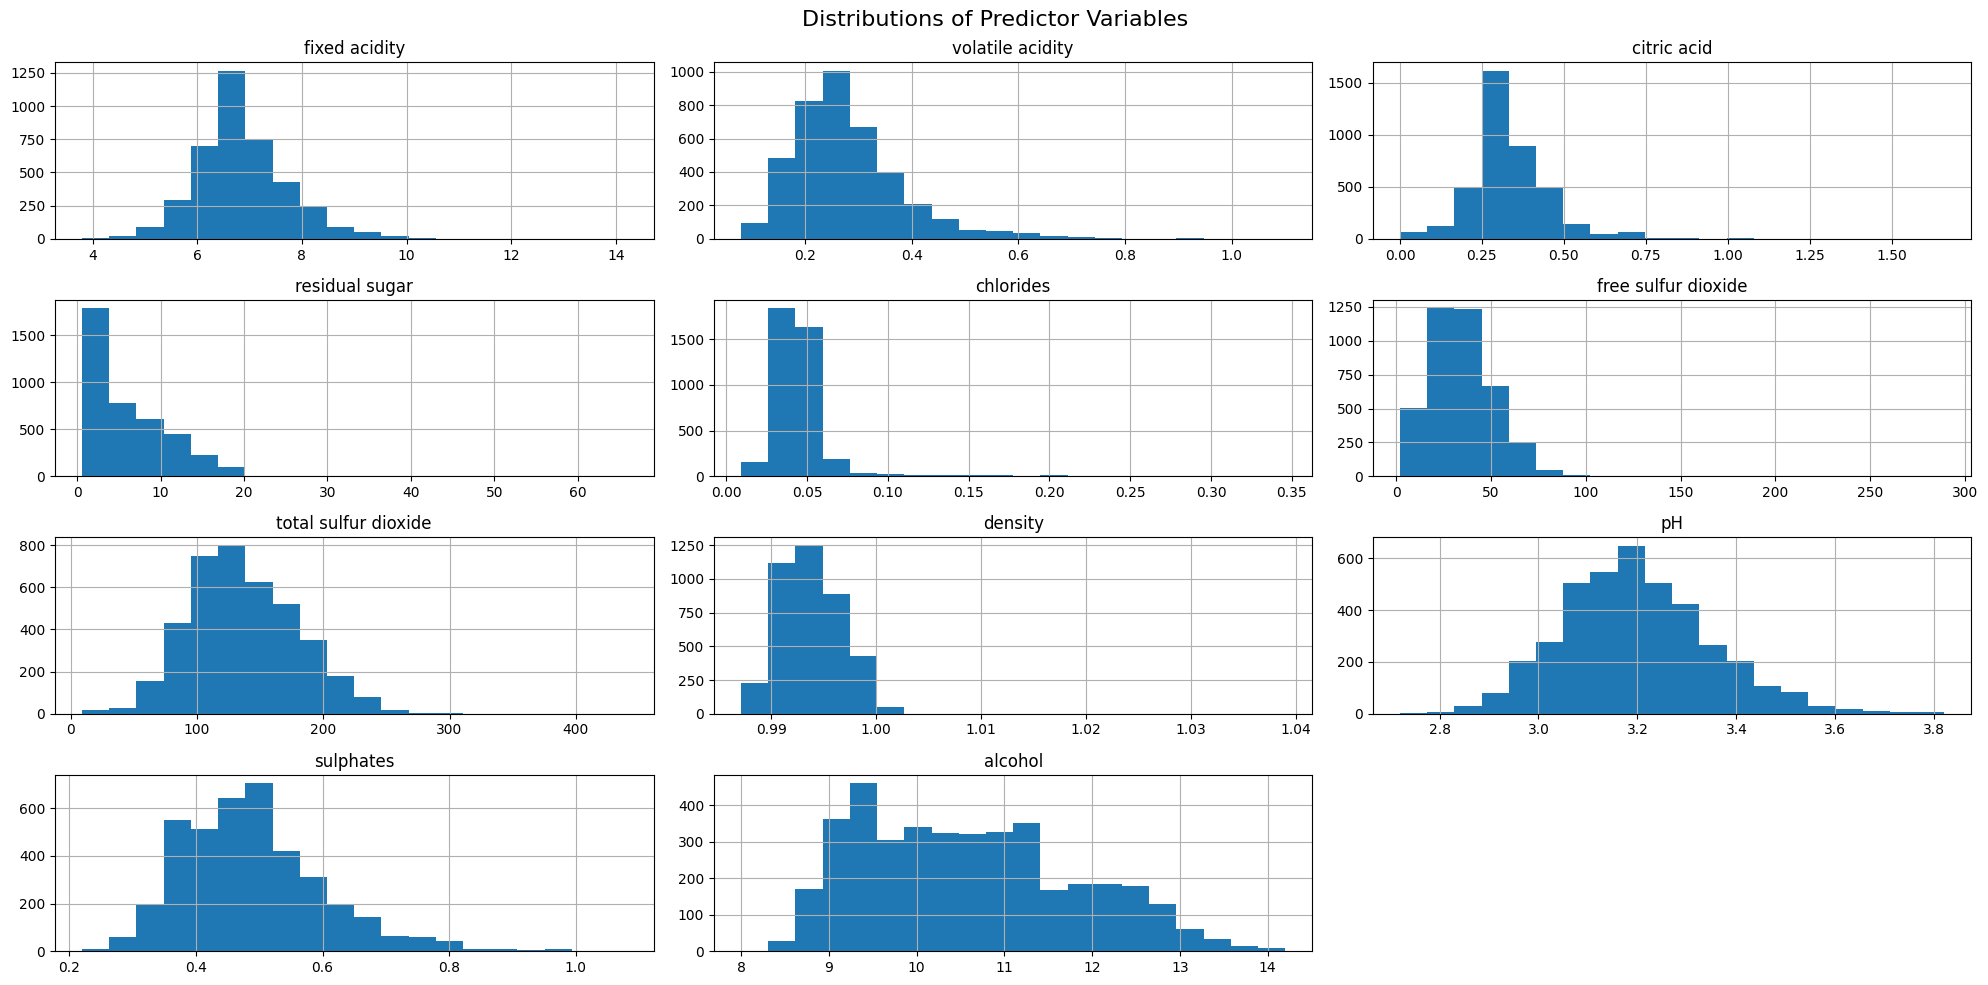

In [ ]:
# Check the distribution of each attribute/feature
df[attributes].hist(bins=20, figsize=(20,10))
plt.suptitle("Distributions of Predictor Variables", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
# All predictors are numerical (no need to convert).
# Normal-like Distributions: fixed acidity, citric acid, total sulfur dioxide, pH, and alcohol look somewhat bell-shaped like a normal distribution
# Skewed Distributions: volatile acidity, residual sugar, chlorides, free sulfur dioxide, sulphates, density have right-skew

In [ ]:
# Possible Explanations for non-normal distributions:
# Common in chemical compositions to have many samples near zero/low values (bounded by zero) and some extreme values creating skew

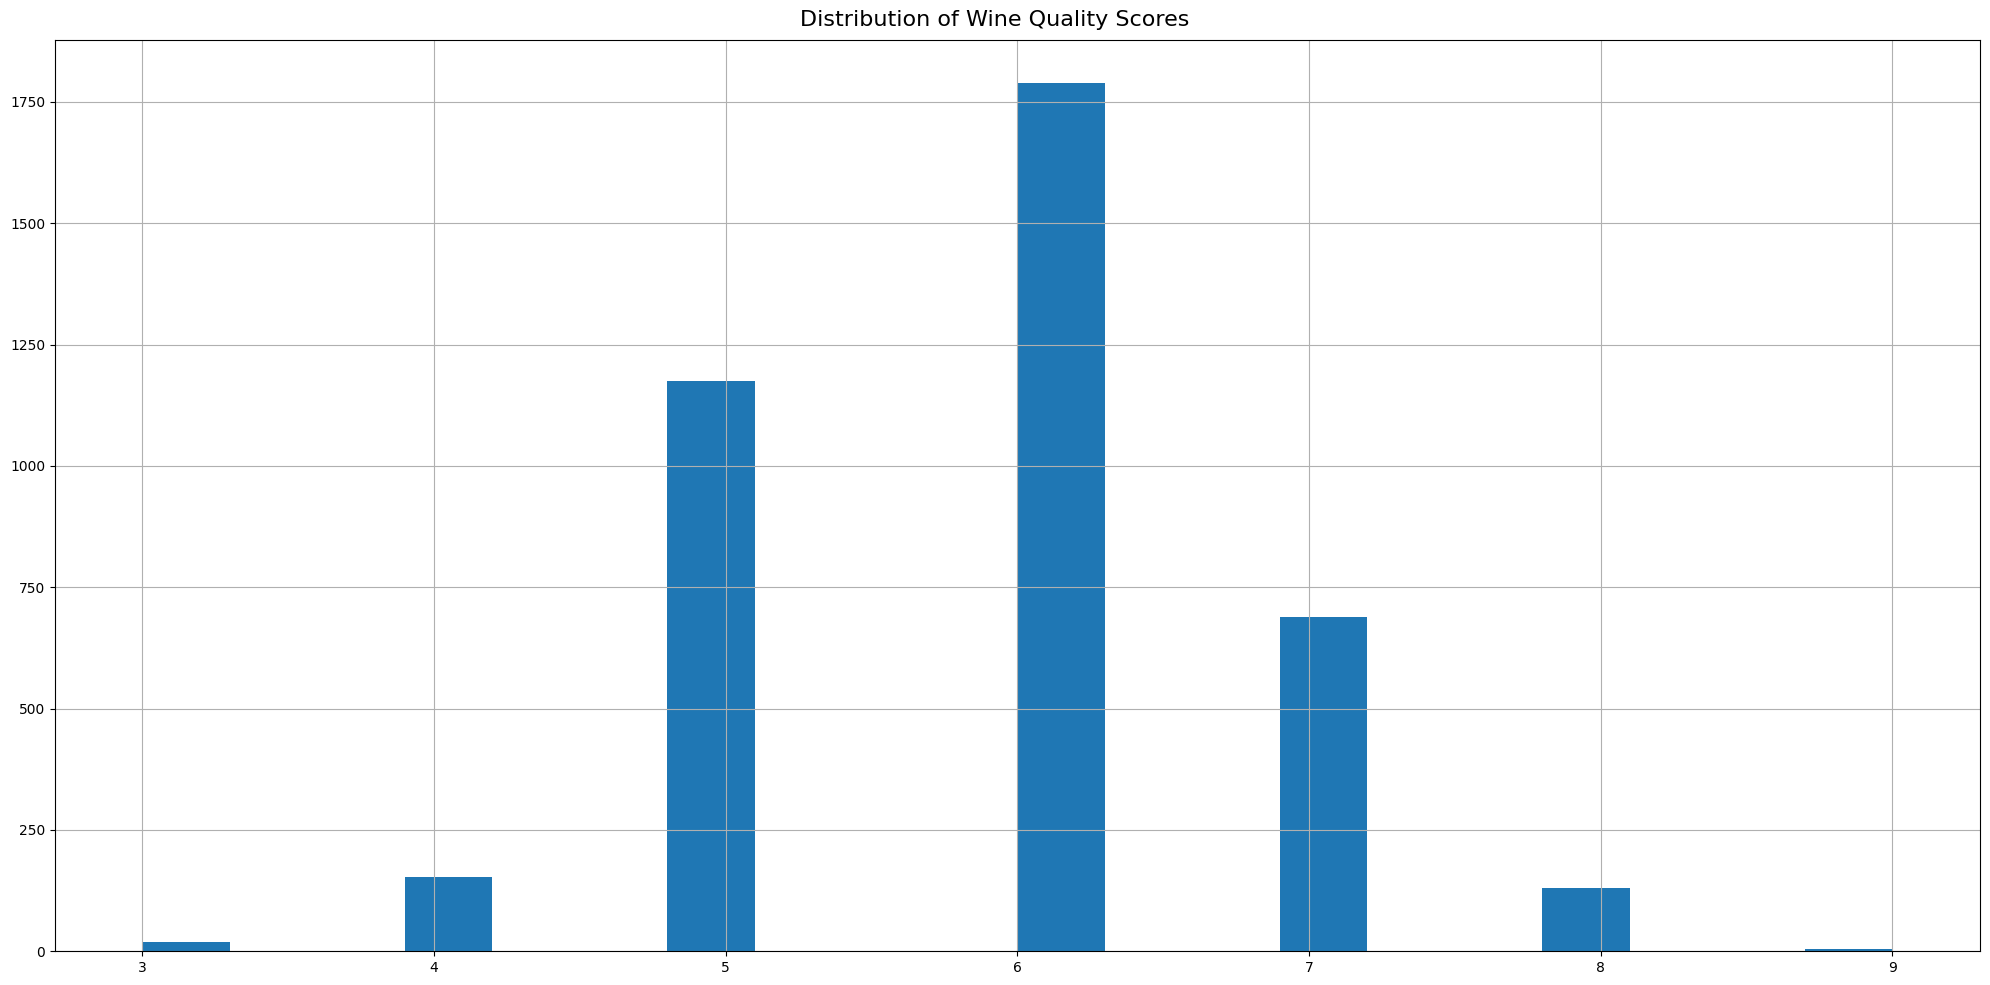

In [ ]:
# Check distribution of the target
df[target].hist(bins=20, figsize=(20,10))
plt.suptitle("Distribution of Wine Quality Scores", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
# Wine quality falls in a range of (3-9), but most are (5-7). There is clear class imbalance, with the target skewed towards average scores (with class 6 being the most frequent)

Standardize and Normalize Attributes

In [ ]:
# Considering that all the features are continuous chemical measurements, normalization is not necessary
# Standardization is necessary because SGD Regressor is scale-sensitive (gradient-based)

Correlation of Attributes and Target

In [ ]:
# create a correlation matrix for the features and the target variables
corr_matrix = df.corr()
corr_matrix

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,-0.019214,0.298959,0.083620,0.024036,-0.058396,0.082425,0.266091,-0.431274,-0.017453,-0.110788,-0.124636
volatile acidity,-0.019214,1.000000,-0.163228,0.098340,0.086287,-0.102471,0.102315,0.060603,-0.046954,-0.021150,0.046815,-0.190678
citric acid,0.298959,-0.163228,1.000000,0.106269,0.132590,0.091681,0.122845,0.160076,-0.183015,0.049442,-0.076514,0.007065
residual sugar,0.083620,0.098340,0.106269,1.000000,0.076091,0.306835,0.409583,0.820498,-0.165997,-0.020503,-0.398167,-0.117339
chlorides,0.024036,0.086287,0.132590,0.076091,1.000000,0.101272,0.191145,0.253088,-0.090573,0.017871,-0.356928,-0.217739
free sulfur dioxide,-0.058396,-0.102471,0.091681,0.306835,0.101272,1.000000,0.619437,0.294638,-0.007750,0.037932,-0.251768,0.010507
total sulfur dioxide,0.082425,0.102315,0.122845,0.409583,0.191145,0.619437,1.000000,0.536868,0.008239,0.136544,-0.446643,-0.183356
density,0.266091,0.060603,0.160076,0.820498,0.253088,0.294638,0.536868,1.000000,-0.063734,0.082048,-0.760162,-0.337805
pH,-0.431274,-0.046954,-0.183015,-0.165997,-0.090573,-0.007750,0.008239,-0.063734,1.000000,0.142353,0.093095,0.123829
sulphates,-0.017453,-0.021150,0.049442,-0.020503,0.017871,0.037932,0.136544,0.082048,0.142353,1.000000,-0.022850,0.053200


<function matplotlib.pyplot.show(close=None, block=None)>

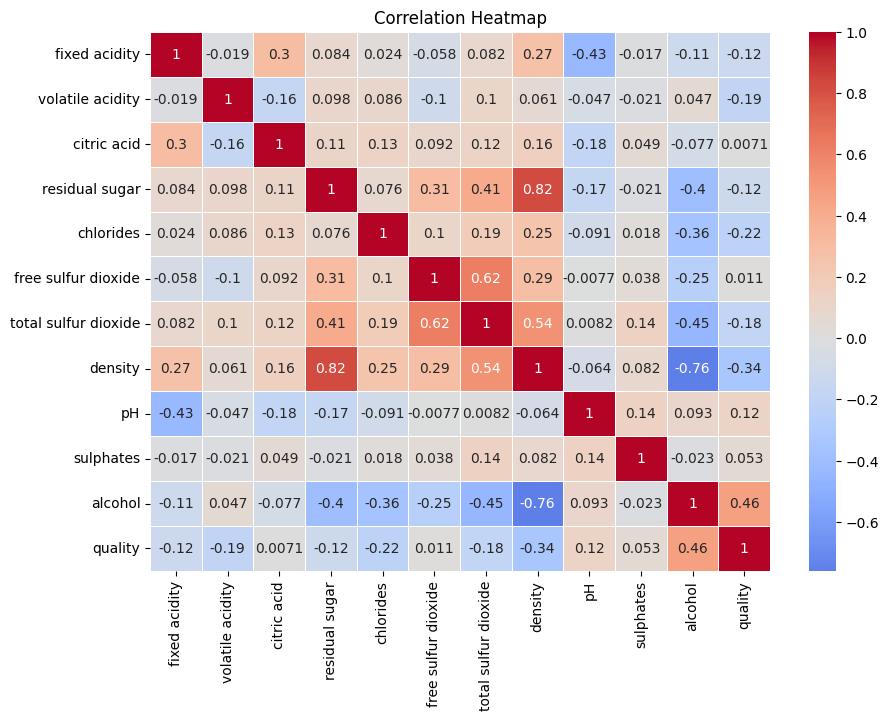

In [ ]:
# create a heatmap of correlations
plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show

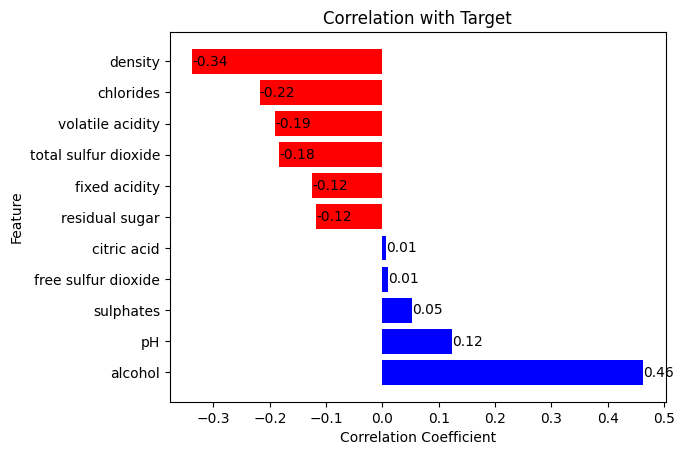

In [ ]:
# create a bar chart of correlation values with target (descending order)
importance = corr_matrix[target].sort_values(ascending=False)[1:]
colors = ['red' if val < 0 else 'blue' for val in importance]
plt.barh(importance.index, importance.values, color=colors)
plt.xlabel('Correlation Coefficient')
plt.ylabel('Feature')
plt.title('Correlation with Target')
# add value labels
for i, val in enumerate(importance.values):
    plt.text(val, i, f'{val:.2f}', ha='left', va='center')

plt.show()

In [ ]:
# Since residual sugar - density have a collinearity of 0.82 and density - alcohol have a collinearity of -0.76 (where alcohol is the strongest predictor of target with 0.46),
# we drop density
# we drop free sulfur dioxide as well, as it is inter-correlated with total sulfur dioxide
# we drop citric acid since it has almost no correlation with quality
# drop density, citric acid and free sulfur dioxide from features
df = df.drop(['density', 'free sulfur dioxide', 'citric acid'], axis=1)
attributes = df.columns[:-1]
target = df.columns[-1]
df

,fixed acidity,volatile acidity,residual sugar,chlorides,total sulfur dioxide,pH,sulphates,alcohol,quality
0,7.0,0.27,20.7,0.045,170.0,3.00,0.45,8.8,6
1,6.3,0.30,1.6,0.049,132.0,3.30,0.49,9.5,6
2,8.1,0.28,6.9,0.050,97.0,3.26,0.44,10.1,6
3,7.2,0.23,8.5,0.058,186.0,3.19,0.40,9.9,6
4,6.2,0.32,7.0,0.045,136.0,3.18,0.47,9.6,6
...,...,...,...,...,...,...,...,...,...
3956,6.2,0.21,1.6,0.039,92.0,3.27,0.50,11.2,6
3957,6.6,0.32,8.0,0.047,168.0,3.15,0.46,9.6,5
3958,6.5,0.24,1.2,0.041,111.0,2.99,0.46,9.4,6
3959,5.5,0.29,1.1,0.022,110.0,3.34,0.38,12.8,7


Testing/Training Split (80/20)

In [ ]:
X = df[attributes].copy()
y = df.copy()
# y = 1 --> High-quality (quality>=7) and y = 0 --> (low-quality and quality < 7)
y = (y['quality'] >= 7).astype(int)

In [ ]:
class_counts = y.value_counts().sort_index()
class_counts

,count
quality,
0,3136
1,825


In [ ]:
# 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)


Train shape: (3168, 8) (3168,)
Test shape: (793, 8) (793,)


In [ ]:
# helper function for metrics: accuracy, recall, precision, f1
def metrics(y_true, y_pred, label=""):
  precision = precision_score(y_true, y_pred, zero_division=0)
  recall = recall_score(y_true, y_pred, zero_division=0)
  accuracy = accuracy_score(y_true, y_pred)
  f1 = f1_score(y_true, y_pred, zero_division=0)
  print(f"{label} Metrics: Precision={precision:.4f} | Recall={recall:.4f} | Accuracy={accuracy:.4f} | F1={f1:.4f}")
  return accuracy, recall, precision, f1

In [ ]:
num_attributes = X.columns.tolist()
scaler = ColumnTransformer(
    transformers = [('num', StandardScaler(), num_attributes)],
    remainder = 'drop'
)

**Model Construction**

---



In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
models = []

Decision Tree

In [ ]:
dt_pipe = Pipeline([
    ('scaler', scaler),
    ('model', DecisionTreeClassifier(random_state=42))
])
param_grid_dt = {
    'model__criterion': ['gini', 'entropy', 'log_loss'],
    'model__max_depth': [None, 3, 5, 10, 20],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__ccp_alpha': [0.0, 0.001, 0.01],
    'model__class_weight': [None, 'balanced']
}
models.append(('Decision Tree', dt_pipe, param_grid_dt))

Random Forest

In [ ]:
rf_pipe = Pipeline([
    ('scaler', scaler),
    ('model', RandomForestClassifier(random_state=42, n_jobs=-1))
])
param_grid_rf = {
    'model__n_estimators': [200, 500],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': [None, 'sqrt', 'log2'],
    'model__class_weight': [None, 'balanced']
}
models.append(('Random Forest', rf_pipe, param_grid_rf))

AdaBoost

In [ ]:
ada_pipe = Pipeline([
    ('scaler', scaler),
    ('model', AdaBoostClassifier(random_state=42))
])
param_grid_ada = {
    'model__n_estimators': [100, 200, 500],
    'model__learning_rate': [0.01, 0.1, 0.5, 1.0],
}
models.append(('AdaBoost', ada_pipe, param_grid_ada))

XGBoost

In [ ]:
xgb_pipe = Pipeline([
    ('scaler', scaler),
    ('model', XGBClassifier(
        random_state=42,
        n_estimators=600,
        tree_method='hist',
        eval_metric='logloss',
        use_label_encoder=False,
        n_jobs=-1
        ))
])
param_grid_xgb = {
    'model__max_depth': [3, 5, 10],
    'model__learning_rate': [0.01, 0.1],
    'model__subsample': [0.7, 1.0],
    'model__colsample_bytree': [0.7, 1.0],
    'model__reg_lambda': [1.0, 5.0],
    'model__min_child_weight': [1, 5]
}
models.append(('XGBoost', xgb_pipe, param_grid_xgb))

In [ ]:
len(models)

4

Hyperparameter Tuning, Evaluation, Confusion Matrix, ROC & Precision-Recall Plots



Fitting 5 folds for each of 60 candidates, totalling 300 fits
Decision Tree Metrics: Precision=0.3706 | Recall=0.7636 | Accuracy=0.6810 | F1=0.4990

Decision Tree -- Best Params: {'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_depth': 3, 'model__criterion': 'entropy', 'model__class_weight': 'balanced', 'model__ccp_alpha': 0.0}
Accuracy: 0.6810  Recall: 0.7636  Precision: 0.3706  F1: 0.4990 ROC AUC: 0.7884, PR AUC: 0.4290

Classification report:
               precision    recall  f1-score   support

           0      0.914     0.659     0.766       628
           1      0.371     0.764     0.499       165

    accuracy                          0.681       793
   macro avg      0.642     0.711     0.632       793
weighted avg      0.801     0.681     0.710       793



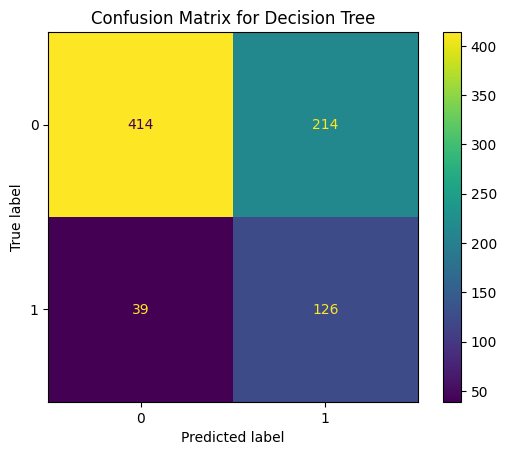

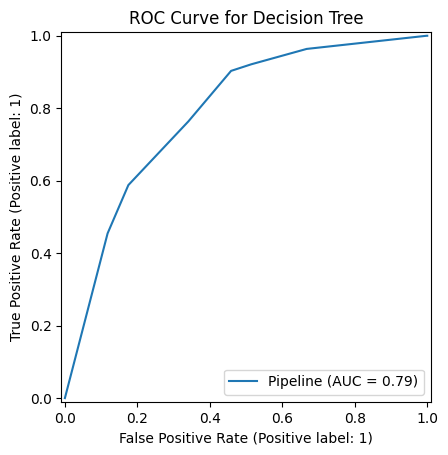

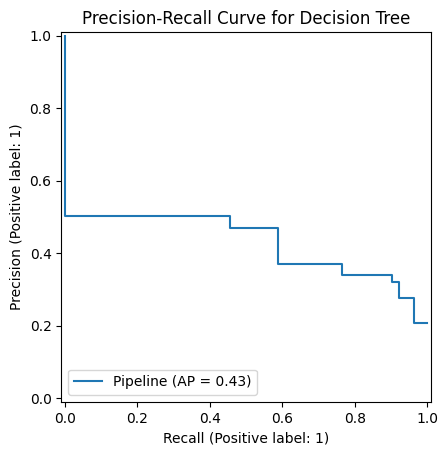

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Random Forest Metrics: Precision=0.4977 | Recall=0.6667 | Accuracy=0.7907 | F1=0.5699

Random Forest -- Best Params: {'model__n_estimators': 500, 'model__min_samples_split': 10, 'model__min_samples_leaf': 2, 'model__max_features': 'sqrt', 'model__max_depth': 10, 'model__class_weight': 'balanced'}
Accuracy: 0.7907  Recall: 0.6667  Precision: 0.4977  F1: 0.5699 ROC AUC: 0.8396, PR AUC: 0.5713

Classification report:
               precision    recall  f1-score   support

           0      0.904     0.823     0.862       628
           1      0.498     0.667     0.570       165

    accuracy                          0.791       793
   macro avg      0.701     0.745     0.716       793
weighted avg      0.819     0.791     0.801       793



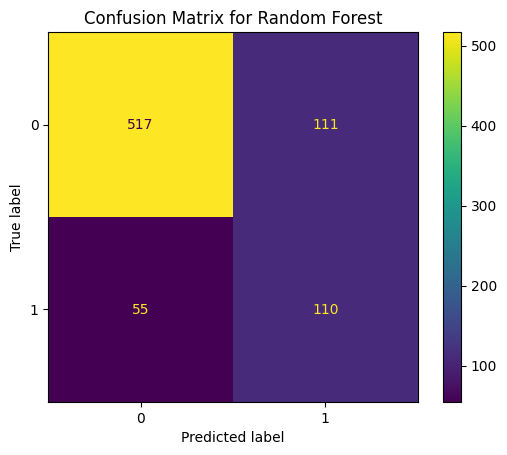

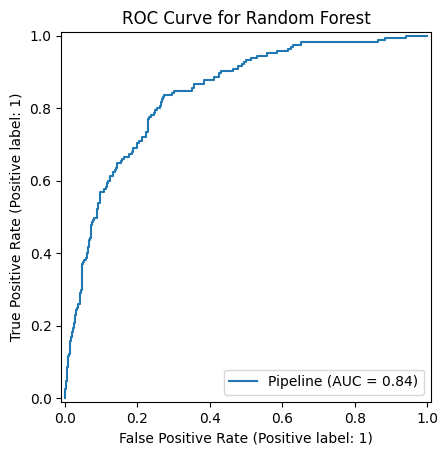

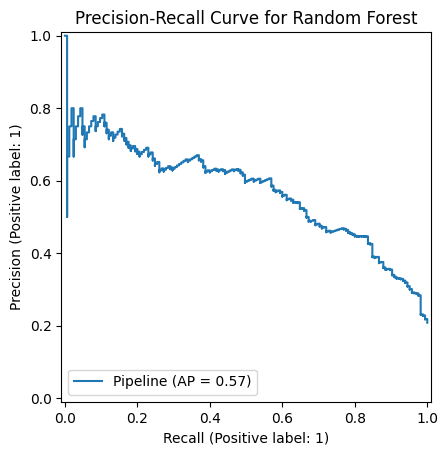

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 12 is smaller than n_iter=60. Running 12 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 5 folds for each of 12 candidates, totalling 60 fits
AdaBoost Metrics: Precision=0.6875 | Recall=0.4000 | Accuracy=0.8373 | F1=0.5057

AdaBoost -- Best Params: {'model__n_estimators': 500, 'model__learning_rate': 1.0}
Accuracy: 0.8373  Recall: 0.4000  Precision: 0.6875  F1: 0.5057 ROC AUC: 0.8217, PR AUC: 0.5559

Classification report:
               precision    recall  f1-score   support

           0      0.858     0.952     0.903       628
           1      0.688     0.400     0.506       165

    accuracy                          0.837       793
   macro avg      0.773     0.676     0.704       793
weighted avg      0.822     0.837     0.820       793



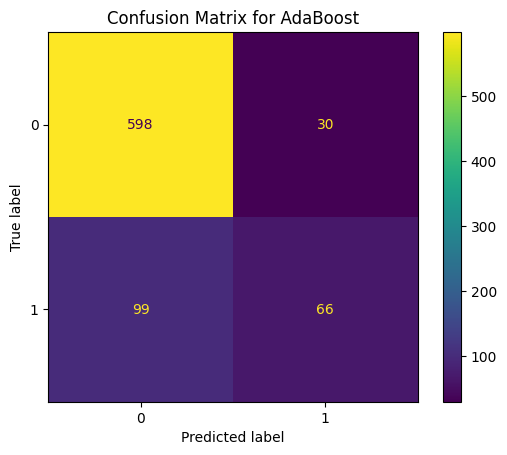

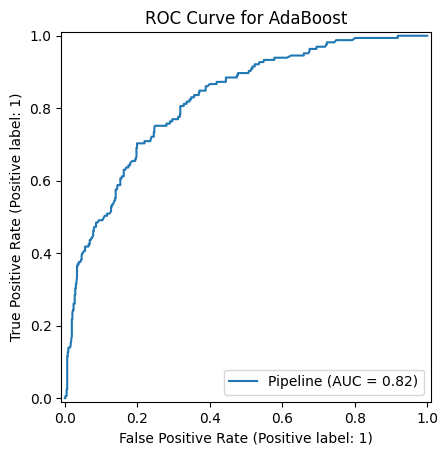

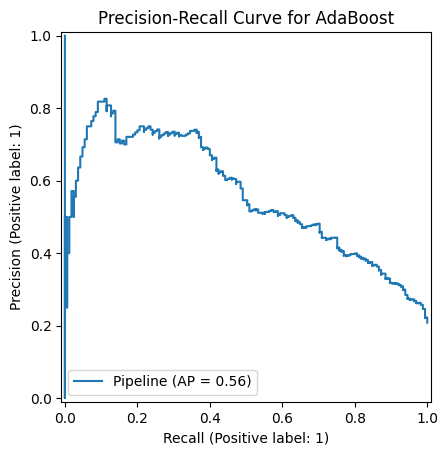

Fitting 5 folds for each of 60 candidates, totalling 300 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [21:17:56] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Metrics: Precision=0.6154 | Recall=0.4364 | Accuracy=0.8260 | F1=0.5106

XGBoost -- Best Params: {'model__subsample': 0.7, 'model__reg_lambda': 5.0, 'model__min_child_weight': 1, 'model__max_depth': 10, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.7}
Accuracy: 0.8260  Recall: 0.4364  Precision: 0.6154  F1: 0.5106 ROC AUC: 0.8298, PR AUC: 0.5678

Classification report:
               precision    recall  f1-score   support

           0      0.862     0.928     0.894       628
           1      0.615     0.436     0.511       165

    accuracy                          0.826       793
   macro avg      0.739     0.682     0.702       793
weighted avg      0.811     0.826     0.814       793



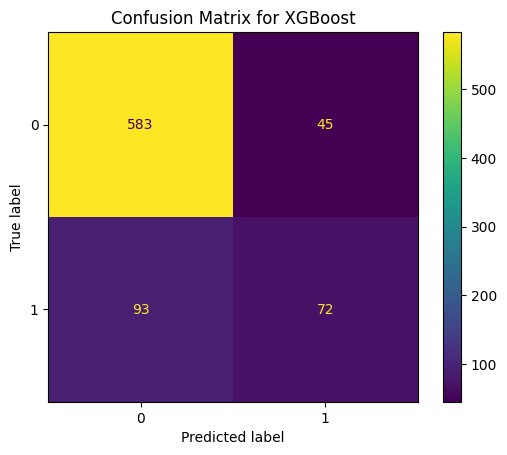

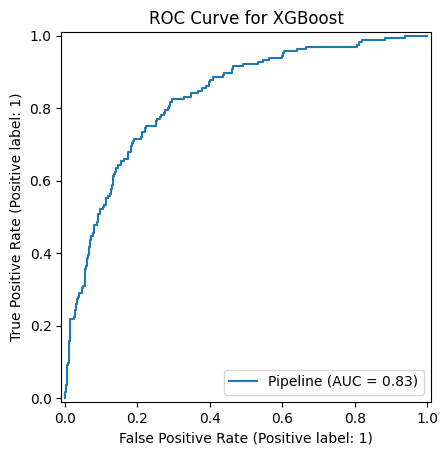

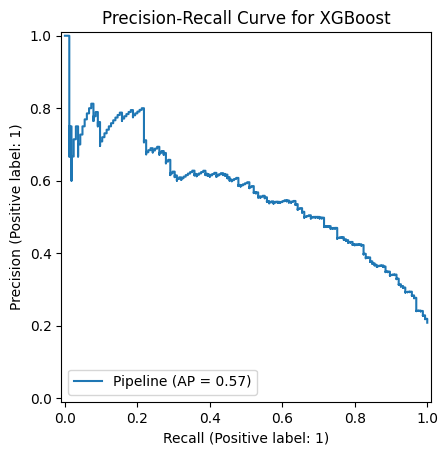

,Model,Best Params,Accuracy,Recall,Precision,F1,ROC AUC,PR AUC
1,Random Forest,"{'model__n_estimators': 500, 'model__min_sampl...",0.790668,0.666667,0.497738,0.569948,0.839597,0.571308
3,XGBoost,"{'model__subsample': 0.7, 'model__reg_lambda':...",0.825977,0.436364,0.615385,0.510638,0.829772,0.567819
2,AdaBoost,"{'model__n_estimators': 500, 'model__learning_...",0.837327,0.400000,0.687500,0.505747,0.821680,0.555887
0,Decision Tree,"{'model__min_samples_split': 2, 'model__min_sa...",0.680958,0.763636,0.370588,0.499010,0.788443,0.429004


In [ ]:
results = []
best_models = {}
for name, model, param_grid in models:
  gs = RandomizedSearchCV(model, param_grid, n_iter=60, scoring='f1', cv=cv, verbose=1, random_state=42, n_jobs=-1)
  gs.fit(X_train, y_train)
  best = gs.best_estimator_
  best_models[name] = best

  # Evaluation
  y_pred = best.predict(X_test)
  y_prob = best.predict_proba(X_test)[:, 1] if hasattr(best, 'predict_proba') else None

  # Performance Metrics
  acc, rec, prec, f1 = metrics(y_test, y_pred, label=name)
  roc = roc_auc_score(y_test, y_prob) if y_prob is not None else None
  pr = average_precision_score(y_test, y_prob) if y_prob is not None else None

  print(f"\n{name} -- Best Params: {gs.best_params_}")
  print(f"Accuracy: {acc:.4f}  Recall: {rec:.4f}  Precision: {prec:.4f}  F1: {f1:.4f} ROC AUC: {roc:.4f}, PR AUC: {pr:.4f}")
  print("\nClassification report:\n", classification_report(y_test, y_pred, digits=3))

  # Confusion Matrix
  ConfusionMatrixDisplay.from_estimator(best, X_test, y_test)
  plt.title(f"Confusion Matrix for {name}")
  plt.show()

  # ROC Curve
  if y_prob is not None:
    RocCurveDisplay.from_estimator(best, X_test, y_test)
    plt.title(f"ROC Curve for {name}")
    plt.show()

    #Precision-Recall Curve
    PrecisionRecallDisplay.from_estimator(best, X_test, y_test)
    plt.title(f"Precision-Recall Curve for {name}")
    plt.show()

  results.append({
      'Model': name,
      'Best Params': gs.best_params_,
      'Accuracy': acc,
      'Recall': rec,
      'Precision': prec,
      'F1': f1,
      "ROC AUC": roc,
      "PR AUC": pr
      })
summary_cls = pd.DataFrame(results).sort_values("F1", ascending=False)
summary_cls

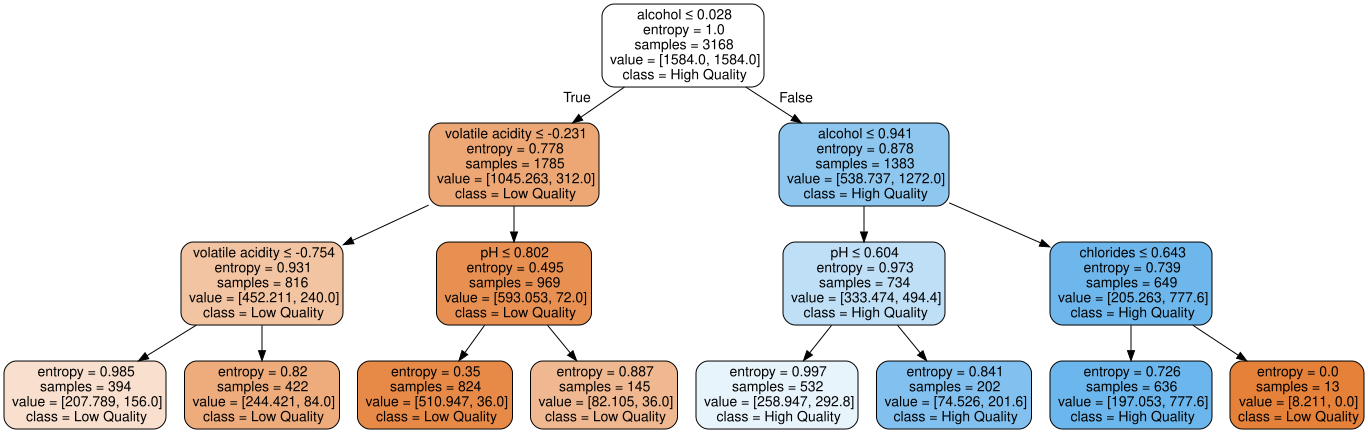

In [ ]:
dt_graph = export_graphviz(
    best_models['Decision Tree'].named_steps['model'],
    out_file=None,
    feature_names=attributes,
    class_names=['Low Quality', 'High Quality'],
    filled=True,
    rounded=True,
    special_characters=True
)
graph = graphviz.Source(dt_graph)
graph

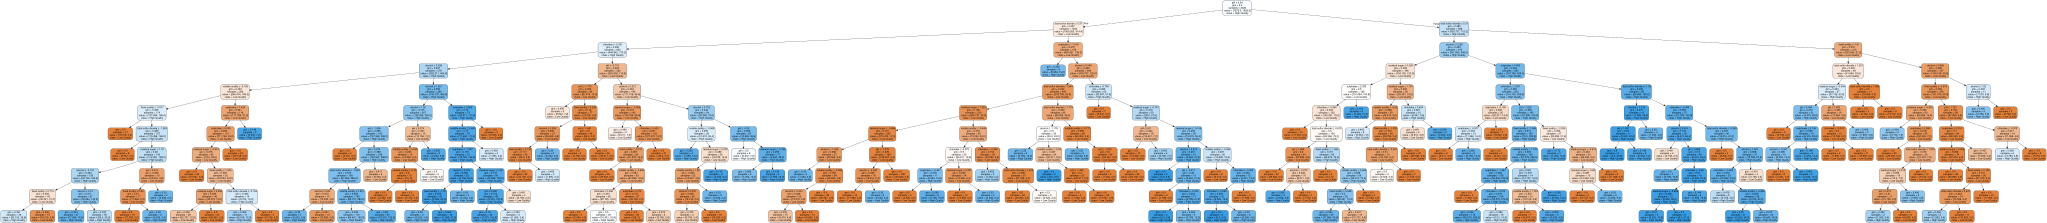

In [ ]:
rf_graph = export_graphviz(
    best_models['Random Forest'].named_steps['model'].estimators_[0],
    out_file=None,
    feature_names=attributes,
    class_names=['Low Quality', 'High Quality'],
    filled=True,
    rounded=True,
    special_characters=True
)
graph = graphviz.Source(rf_graph)
graph

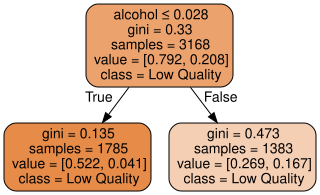

In [ ]:
ada_graph = export_graphviz(
    best_models['AdaBoost'].named_steps['model'].estimators_[0],
    out_file=None,
    feature_names=attributes,
    class_names=['Low Quality', 'High Quality'],
    filled=True,
    rounded=True,
    special_characters=True
)
graph = graphviz.Source(ada_graph)
graph